# King County House Price Prediction

Proje Amacı: Bu projede ABD Washington Eyaleti King İlçesi ev fiyatlarını tahmin eden bir regresyon modeli geliştirilecektir. Hedefler:

R2 değerinin 0.80'den büyük olması
RMSE değerinin $100,000'den küçük olması
Veri Seti: kc_house_data.csv dosyasındaki King İlçesi ev verileri kullanılacaktır.

Veri Analizi ve Ön İşleme:

Veri keşif analizi (EDA) yapılarak verilerin özelliklerinin anlaşılması
Aykırı değerlerin temizlenmesi
Öznitelik mühendisliği (feature engineering) ile yeni özniteliklerin oluşturulması
Modelleme:

Çeşitli regresyon algoritmalarının (lineer regresyon, karar ağaçları, rassal ormanlar, XGBoost vb.) test edilmesi
En iyi performans veren modelin seçilmesi
Değerlendirme:

Seçilen modelin test verileri üzerinde R2 ve RMSE değerlerinin hesaplanması
Hedeflenen başarı kriterlerinin karşılanıp karşılanmadığının kontrolü

<img src=https://solsmart.org/wp-content/uploads/imported-files/assessors_social-600x360-c-default.webp>

In [1]:
import pandas as pd

In [2]:
import pandas as pd
pd.set_option('display.max_columns',55)

import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

import numpy as np #math paketi matrix islemleri

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# import data

In [4]:
df=pd.read_csv('kc_house_data.csv')

In [5]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### EDA-Exploratory Data Analsis - Kesifcil Veri Analizi

In [6]:
df.tail()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,1523300157,20141015T000000,325000.0,2,0.75,1020,1076,2.0,0,0,3,7,1020,0,2008,0,98144,47.5941,-122.299,1020,1357


In [7]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [9]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [10]:
df.corr(numeric_only=True)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.016762,0.001286,0.005160,-0.012258,-0.132109,0.018525,-0.002721,0.011592,-0.023783,0.008130,-0.010842,-0.005151,0.021380,-0.016907,-0.008224,-0.001891,0.020799,-0.002901,-0.138798
price,-0.016762,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.001286,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.005160,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,-0.012258,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,-0.132109,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.018525,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.002721,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.011592,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,-0.023783,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406


In [11]:
df.shape

(21613, 21)

<Axes: >

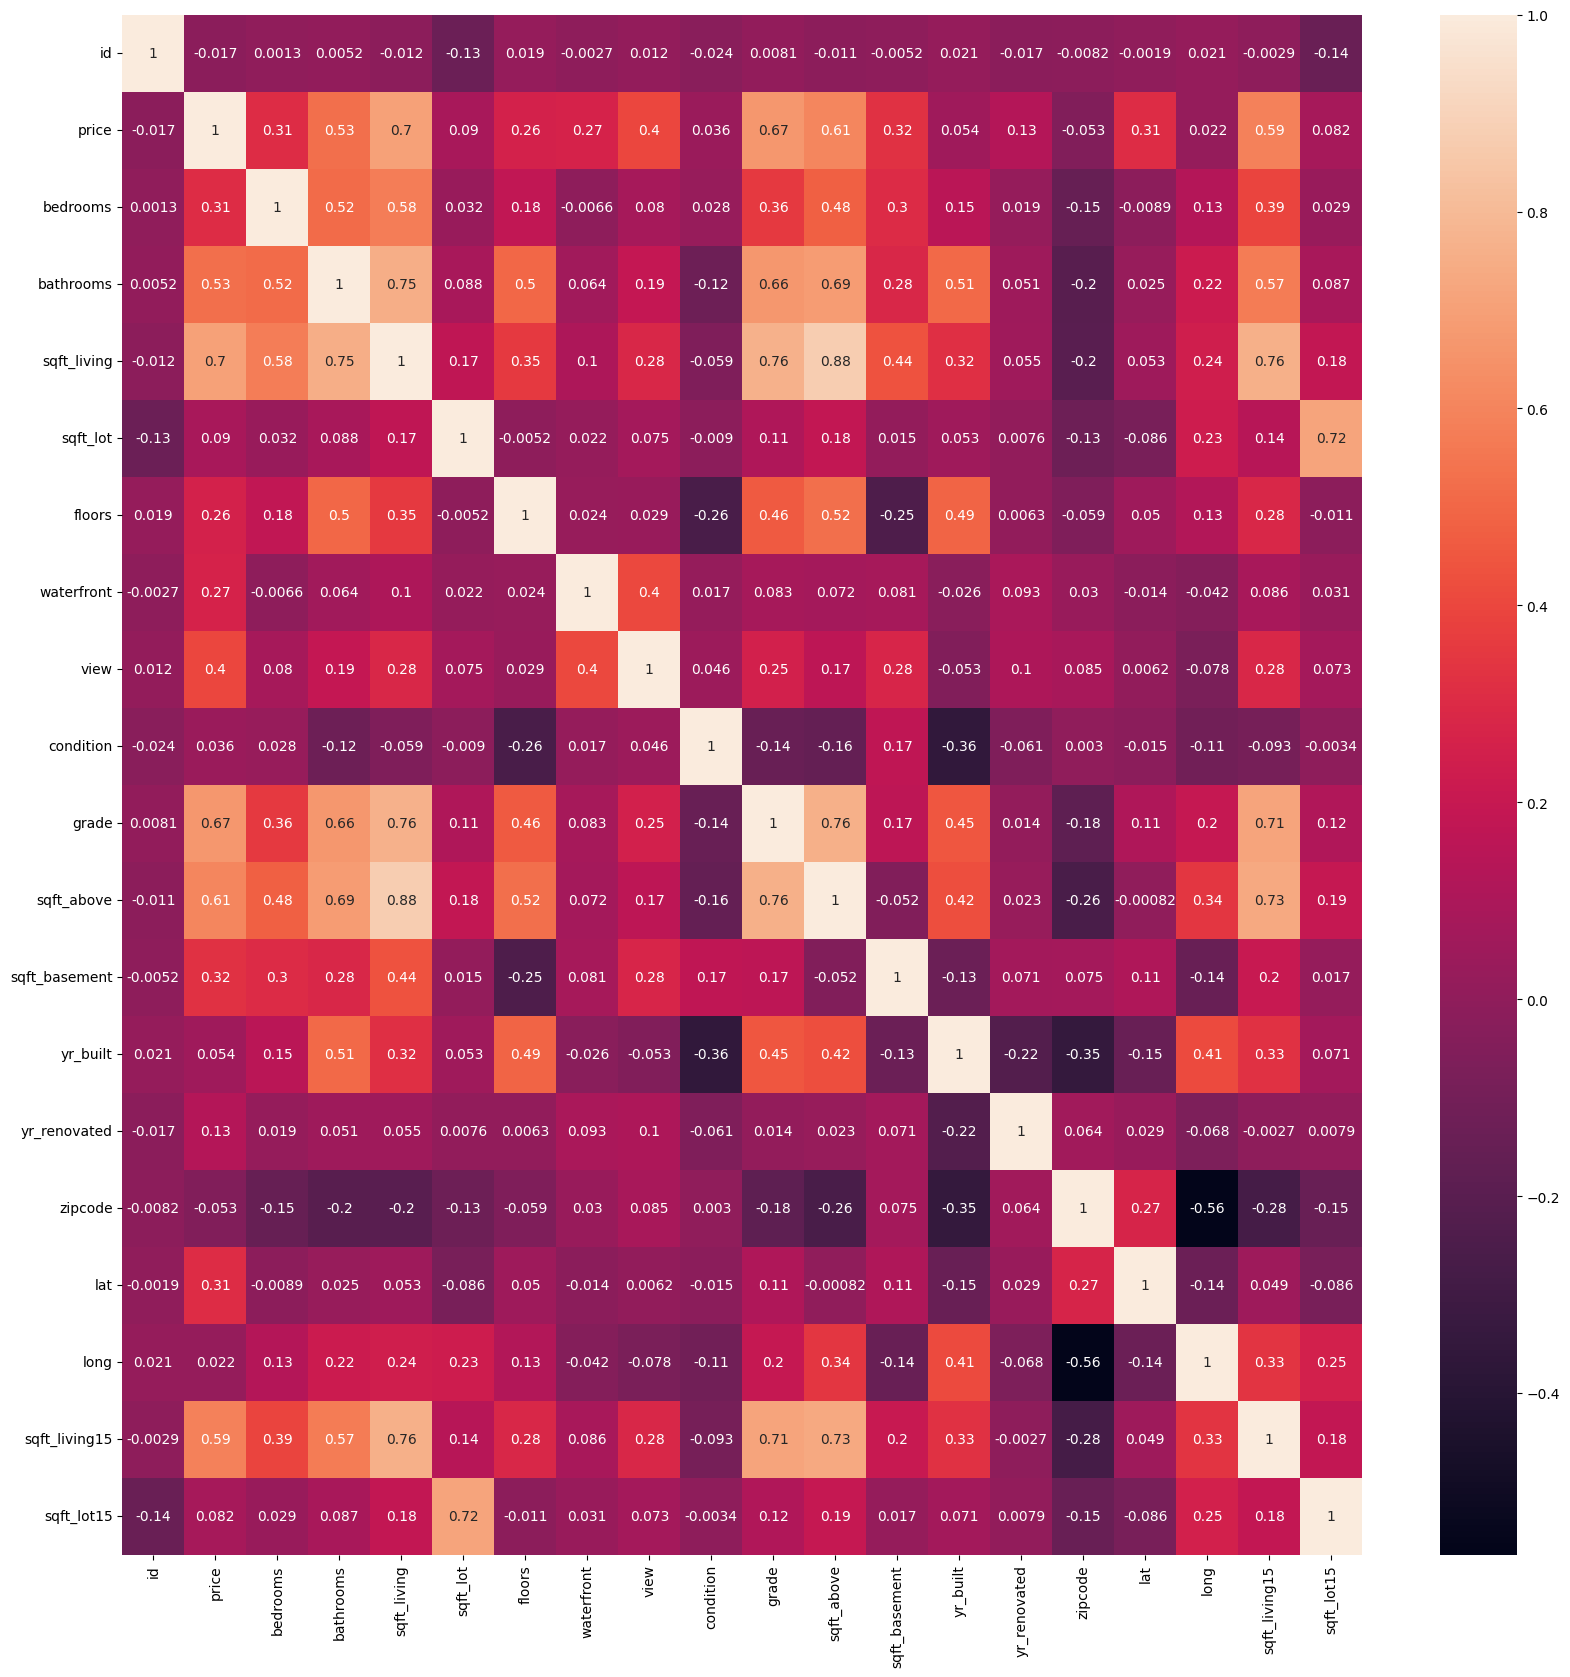

In [12]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [13]:
 abs(df.corr(numeric_only=True))['price'].sort_values(ascending=False)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
zipcode          0.053203
condition        0.036362
long             0.021626
id               0.016762
Name: price, dtype: float64

In [14]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

<Axes: xlabel='bedrooms'>

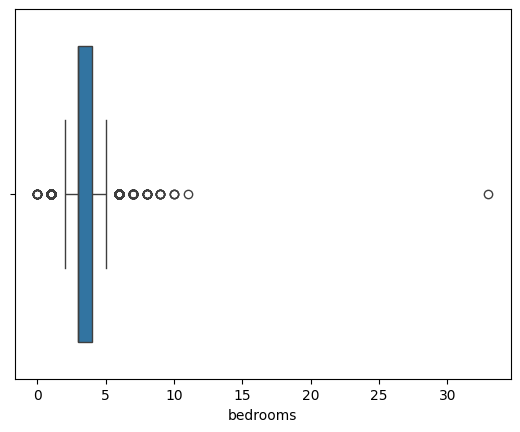

In [15]:
sns.boxplot(x=df['bedrooms'])

In [16]:
df['bedrooms'].mean()+3*df['bedrooms'].std()

np.float64(6.1610271165396)

<Axes: xlabel='bathrooms'>

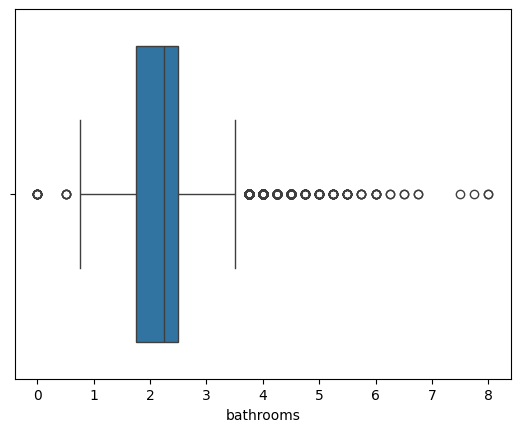

In [17]:
sns.boxplot(x=df['bathrooms'])

In [18]:
df[df['bedrooms']>30]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
15870,2402100895,20140625T000000,640000.0,33,1.75,1620,6000,1.0,0,0,5,7,1040,580,1947,0,98103,47.6878,-122.331,1330,4700


<Axes: xlabel='sqft_living'>

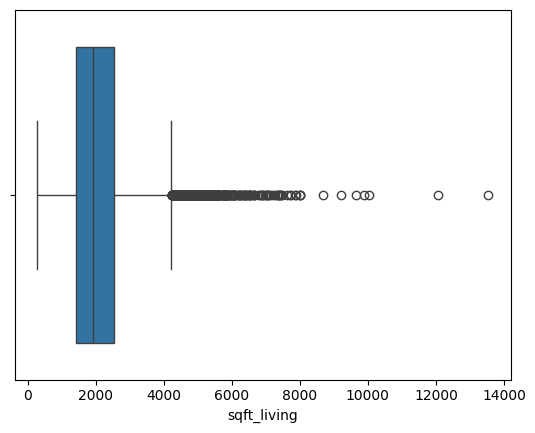

In [19]:
sns.boxplot(x=df['sqft_living'])

<Axes: xlabel='bedrooms', ylabel='count'>

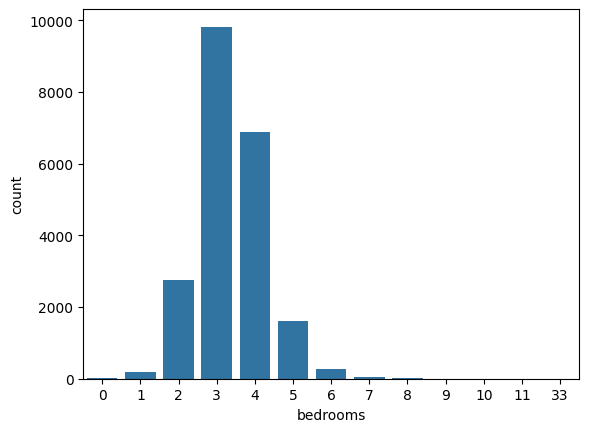

In [20]:
sns.countplot(x=df['bedrooms'])

In [21]:
outliers=df.quantile(q=.97,numeric_only=True)

In [22]:
df=df[(df['price']<outliers['price'])]
df=df[(df['bedrooms']<outliers['bedrooms'])]
df=df[(df['bathrooms']<outliers['bathrooms'])]
df=df[(df['sqft_living']<outliers['sqft_living'])]

<Axes: xlabel='bedrooms', ylabel='count'>

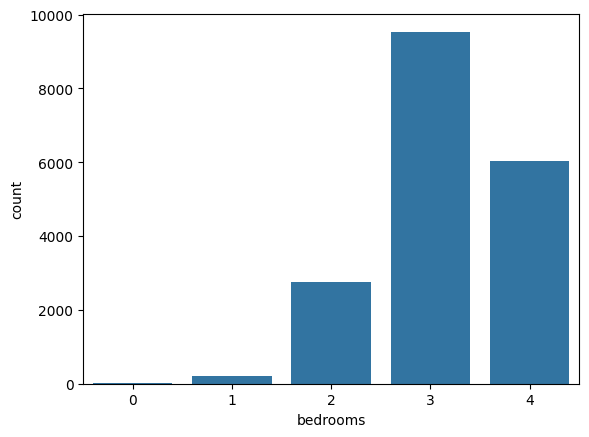

In [23]:
sns.countplot(x=df['bedrooms'])

### Feature Engineerring

In [24]:
df.shape

(18519, 21)

In [25]:
df['zipcode']=df['zipcode'].astype('object')

In [26]:
df['bedrooms']=df['bedrooms']**2
df['bathrooms']=df['bathrooms']**2
df['sqft_living']=df['sqft_living']**2

In [27]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,9,1.0000,1392400,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,9,5.0625,6604900,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,4,1.0000,592900,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,16,9.0000,3841600,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,9,4.0000,2822400,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [28]:
import datetime

In [29]:
datetime.datetime.now().year

2026

In [30]:
df['age']=datetime.datetime.now().year-df['yr_built']

In [31]:
# correlation doesnot mean cousation

In [32]:
df['yr_renovated']=np.where(df['yr_renovated']>0,1,0)
df['sqft_basement']=np.where(df['sqft_basement']>0,1,0)

In [33]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15', 'age'],
      dtype='object')

In [34]:
x=df.drop(['id','date','lat','price'],axis=1) #axcis=1 sutun siler axis=0 satır siler
y=df[['price']]

In [35]:
x=pd.get_dummies(x,drop_first=True)

In [36]:
x.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,long,sqft_living15,sqft_lot15,age,zipcode_98002,zipcode_98003,zipcode_98004,zipcode_98005,zipcode_98006,zipcode_98007,zipcode_98008,zipcode_98010,zipcode_98011,zipcode_98014,...,zipcode_98105,zipcode_98106,zipcode_98107,zipcode_98108,zipcode_98109,zipcode_98112,zipcode_98115,zipcode_98116,zipcode_98117,zipcode_98118,zipcode_98119,zipcode_98122,zipcode_98125,zipcode_98126,zipcode_98133,zipcode_98136,zipcode_98144,zipcode_98146,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199
0,9,1.0000,1392400,5650,1.0,0,0,3,7,1180,0,1955,0,-122.257,1340,5650,71,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,9,5.0625,6604900,7242,2.0,0,0,3,7,2170,1,1951,1,-122.319,1690,7639,75,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,4,1.0000,592900,10000,1.0,0,0,3,6,770,0,1933,0,-122.233,2720,8062,93,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,16,9.0000,3841600,5000,1.0,0,0,5,7,1050,1,1965,0,-122.393,1360,5000,61,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
4,9,4.0000,2822400,8080,1.0,0,0,3,8,1680,0,1987,0,-122.045,1800,7503,39,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [37]:
x.shape

(18519, 86)

In [38]:
x_train, x_test, y_train, y_test=train_test_split(x,y, random_state=42, test_size=0.20)

In [39]:
lr=LinearRegression()

In [40]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
tahmin=lr.predict(x_test)

In [42]:
r2_score(y_test,tahmin)

0.8314480285567748

In [43]:
mean_squared_error(y_test,tahmin)**5

2.614690713911635e+49

In [44]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error

# Linear / Regularized
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                  SGDRegressor, HuberRegressor, RANSACRegressor,
                                  BayesianRidge, OrthogonalMatchingPursuit)
# Tree
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              HistGradientBoostingRegressor, AdaBoostRegressor)
# Neighbors
from sklearn.neighbors import KNeighborsRegressor
# SVR / Kernel
from sklearn.svm import SVR, NuSVR
from sklearn.kernel_ridge import KernelRidge
# Neural Net
from sklearn.neural_network import MLPRegressor
# Boosting
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Yellowbrick
from yellowbrick.regressor import PredictionError, ResidualsPlot

# Suppress warnings
warnings.filterwarnings("ignore")

def algo_test(x, y, plot=True, yellowbrick_viz=False):
    # ======================
    # Define Regression Models
    # ======================
    algos = [
        LinearRegression(),
        Ridge(),
        Lasso(),
        ElasticNet(),
        SGDRegressor(max_iter=1000, tol=1e-3),
        HuberRegressor(),
        RANSACRegressor(),
        BayesianRidge(),
        OrthogonalMatchingPursuit(),
        ExtraTreeRegressor(),
        DecisionTreeRegressor(),
        RandomForestRegressor(),
        GradientBoostingRegressor(),
        HistGradientBoostingRegressor(),
        AdaBoostRegressor(),
        XGBRegressor(verbosity=0, n_jobs=-1),
        CatBoostRegressor(verbose=0),
        KNeighborsRegressor(),
        SVR(),
        NuSVR(),
        KernelRidge(),
        MLPRegressor(max_iter=500, hidden_layer_sizes=(100,50))
    ]

    algo_names = [
        'Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 
        'Huber', 'RANSAC', 'BayesianRidge', 'OMP',
        'Extra Tree', 'Decision Tree', 'Random Forest', 'Gradient Boosting',
        'HistGradientBoosting', 'AdaBoost', 'XGBoost', 'CatBoost',
        'KNN', 'SVR', 'NuSVR', 'KernelRidge', 'MLP'
    ]

    # ======================
    # Train/Test Split
    # ======================
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.20, random_state=42
    )

    results = []

    # ======================
    # Fit Models & Evaluate
    # ======================
    for name, algo in zip(algo_names, algos):
        try:
            # Scale only non-tree models
            if name not in ['Extra Tree', 'Decision Tree', 'Random Forest',
                            'Gradient Boosting', 'HistGradientBoosting',
                            'AdaBoost', 'XGBoost', 'CatBoost']:
                scaler = MinMaxScaler()
                x_train_scaled = scaler.fit_transform(x_train)
                x_test_scaled = scaler.transform(x_test)
            else:
                x_train_scaled = x_train
                x_test_scaled = x_test

            # Fit and predict
            preds = algo.fit(x_train_scaled, y_train).predict(x_test_scaled)
            r2 = r2_score(y_test, preds)
            rmse = mean_squared_error(y_test, preds)
        except Exception as e:
            r2 = None
            rmse = None
            print(f"Model {name} failed: {e}")

        results.append({
            "Model": name,
            "R2": r2,
            "RMSE": rmse
        })

        # ======================
        # Yellowbrick visualizations
        # ======================
        if yellowbrick_viz:
            try:
                # Prediction Error
                plt.figure(figsize=(10, 6))
                visualizer = PredictionError(algo)
                visualizer.fit(x_train_scaled, y_train)
                visualizer.score(x_test_scaled, y_test)
                visualizer.show()

                # Residuals Plot
                plt.figure(figsize=(10, 6))
                visualizer = ResidualsPlot(algo)
                visualizer.fit(x_train_scaled, y_train)
                visualizer.score(x_test_scaled, y_test)
                visualizer.show()

            except Exception as e:
                print(f"Yellowbrick visualizations for {name} failed: {e}")

    # ======================
    # Results Table
    # ======================
    result_df = pd.DataFrame(results).sort_values("R2", ascending=False)
    
    print("\n=== Regression Model Comparison ===\n")
    print(result_df.reset_index(drop=True))

    # ======================
    # Seaborn Plots
    # ======================
    if plot:
        plt.figure(figsize=(18, 7))

        # R2 Score
        plt.subplot(1, 2, 1)
        sns.barplot(data=result_df, x="Model", y="R2", palette="viridis")
        plt.title("R² Score Comparison (Higher is Better)")
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis="y", alpha=0.3)

        # RMSE
        plt.subplot(1, 2, 2)
        sns.barplot(data=result_df, x="Model", y="RMSE", palette="magma")
        plt.title("RMSE Comparison (Lower is Better)")
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis="y", alpha=0.3)

        plt.tight_layout()
        plt.show()

        # RMSE vs R2 scatter
        plt.figure(figsize=(12, 6))
        sns.scatterplot(data=result_df, x="RMSE", y="R2", hue="Model", s=150)
        for i, row in result_df.iterrows():
            plt.text(row["RMSE"], row["R2"], row["Model"], fontsize=9)
        plt.title("Regression Model Trade-off: RMSE vs R²")
        plt.xlabel("RMSE (Lower is Better)")
        plt.ylabel("R² (Higher is Better)")
        plt.grid(alpha=0.3)
        plt.show()

    return result_df


=== Regression Model Comparison ===

                   Model        R2          RMSE
0               CatBoost  0.864853  6.131363e+09
1                XGBoost  0.847372  6.924431e+09
2   HistGradientBoosting  0.845702  7.000185e+09
3                    MLP  0.837410  7.376410e+09
4                  Lasso  0.831449  7.646850e+09
5                 Linear  0.831448  7.646876e+09
6          BayesianRidge  0.831413  7.648469e+09
7            KernelRidge  0.830727  7.679600e+09
8                  Ridge  0.830727  7.679601e+09
9                    SGD  0.819901  8.170722e+09
10                 Huber  0.817446  8.282121e+09
11         Random Forest  0.817190  8.293731e+09
12                   KNN  0.778486  1.004964e+10
13     Gradient Boosting  0.757956  1.098107e+10
14                RANSAC  0.721563  1.263213e+10
15            Extra Tree  0.666415  1.513413e+10
16         Decision Tree  0.602689  1.802524e+10
17                   OMP  0.596594  1.830175e+10
18              AdaBoost  0.364

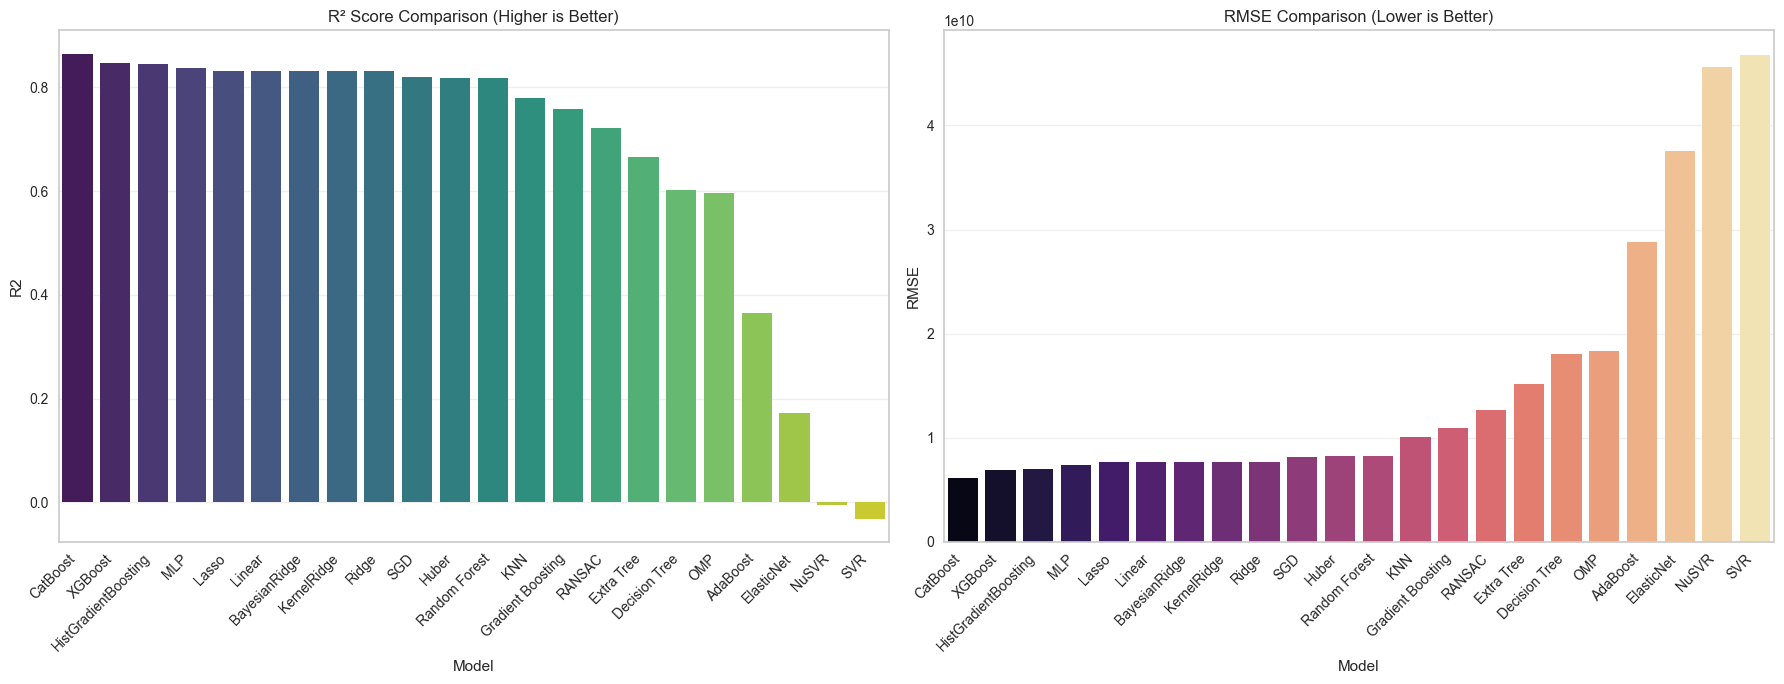

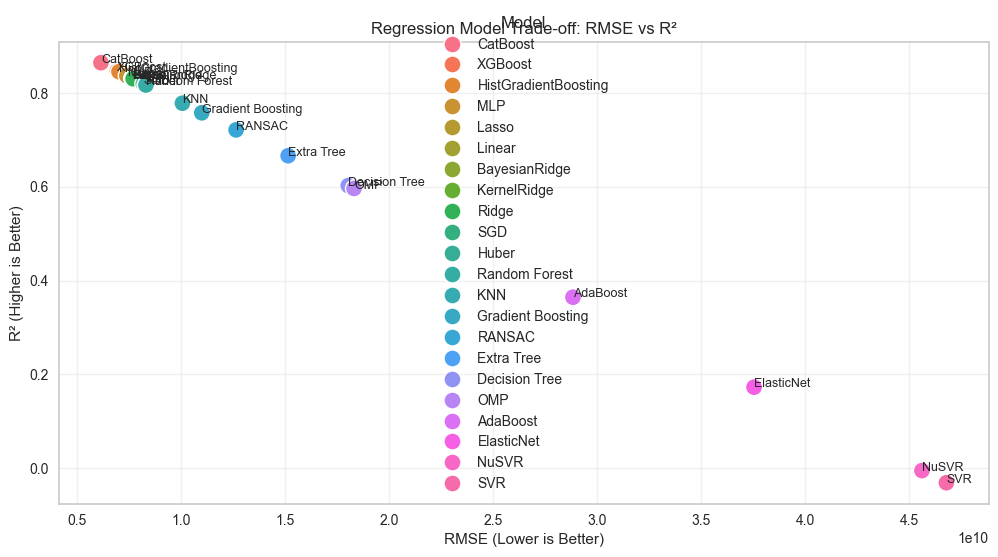

,Model,R2,RMSE
16,CatBoost,0.864853,6.131363e+09
15,XGBoost,0.847372,6.924431e+09
13,HistGradientBoosting,0.845702,7.000185e+09
21,MLP,0.837410,7.376410e+09
2,Lasso,0.831449,7.646850e+09
0,Linear,0.831448,7.646876e+09
7,BayesianRidge,0.831413,7.648469e+09
20,KernelRidge,0.830727,7.679600e+09
1,Ridge,0.830727,7.679601e+09
4,SGD,0.819901,8.170722e+09


In [45]:
algo_test(x,y)

In [46]:
pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.


In [47]:
from yellowbrick.regressor import ResidualsPlot

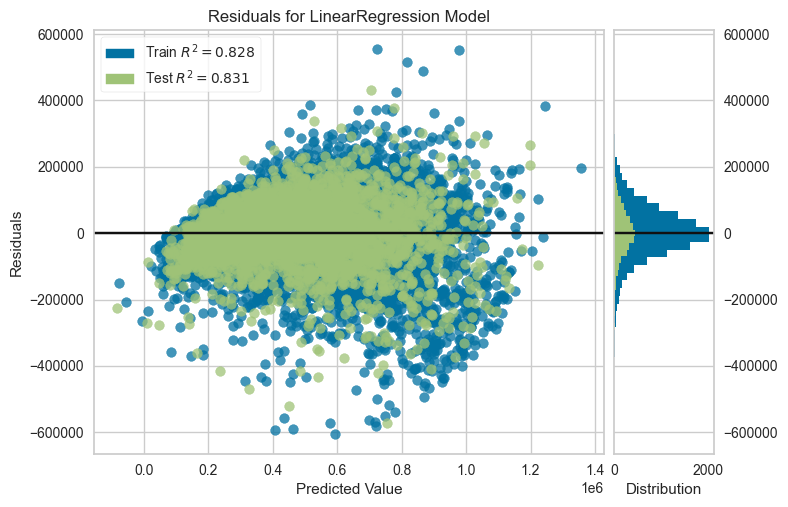

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [48]:
ben=ResidualsPlot(lr)
ben.fit(x_train,y_train)
ben.score(x_test,y_test)
ben.show()

In [49]:
from yellowbrick.regressor import ResidualsPlot

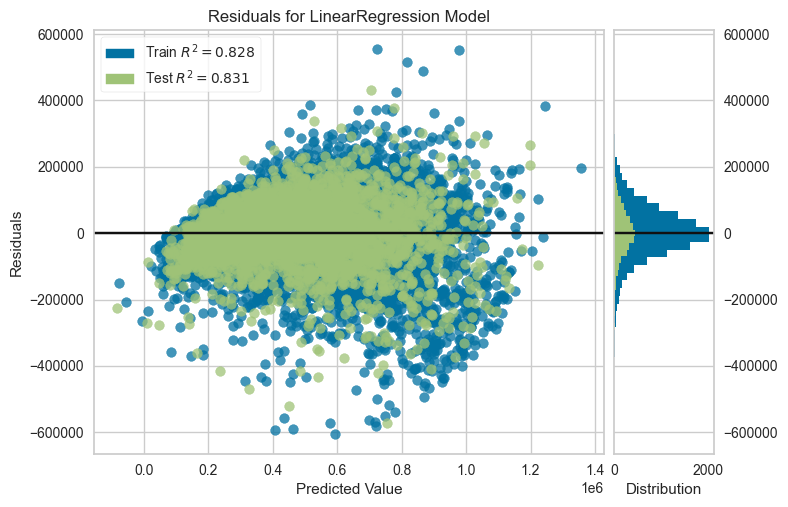

In [50]:
vis=ResidualsPlot(lr)
vis.fit(x_train,y_train)
vis.score(x_test,y_test)
vis.show();

In [51]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,age
0,7129300520,20141013T000000,221900.0,9,1.0000,1392400,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,71
1,6414100192,20141209T000000,538000.0,9,5.0625,6604900,7242,2.0,0,0,3,7,2170,1,1951,1,98125,47.7210,-122.319,1690,7639,75
2,5631500400,20150225T000000,180000.0,4,1.0000,592900,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,93
3,2487200875,20141209T000000,604000.0,16,9.0000,3841600,5000,1.0,0,0,5,7,1050,1,1965,0,98136,47.5208,-122.393,1360,5000,61
4,1954400510,20150218T000000,510000.0,9,4.0000,2822400,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,39


In [52]:
from sklearn.preprocessing import MinMaxScaler

In [53]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [54]:
tahmin=lr.predict(x_test)

In [55]:
r2_score(y_test,tahmin)

0.8314480285567748

In [56]:
from sklearn.tree import DecisionTreeRegressor

In [57]:
dt=DecisionTreeRegressor()

In [58]:
dt.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [59]:
dtahmin=dt.predict(x_test)

In [60]:
r2_score(y_test,dtahmin)

0.5898236226048426

In [61]:
x_test

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,long,sqft_living15,sqft_lot15,age,zipcode_98002,zipcode_98003,zipcode_98004,zipcode_98005,zipcode_98006,zipcode_98007,zipcode_98008,zipcode_98010,zipcode_98011,zipcode_98014,...,zipcode_98105,zipcode_98106,zipcode_98107,zipcode_98108,zipcode_98109,zipcode_98112,zipcode_98115,zipcode_98116,zipcode_98117,zipcode_98118,zipcode_98119,zipcode_98122,zipcode_98125,zipcode_98126,zipcode_98133,zipcode_98136,zipcode_98144,zipcode_98146,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199
11472,4,1.0000,756900,6150,1.0,0,0,3,6,870,0,1941,0,-122.347,1120,6150,85,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7731,16,6.2500,10368400,38448,2.0,0,0,3,10,3220,0,1993,0,-122.053,3090,38448,33,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11890,16,1.0000,2310400,80150,1.0,0,0,2,5,1520,0,1948,0,-121.769,1740,84506,78,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
18295,9,3.0625,1904400,8182,1.0,0,0,5,7,1380,0,1942,0,-122.349,1300,8188,84,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
14487,9,6.2500,5428900,8627,1.0,0,0,4,7,1480,1,1980,0,-122.210,1940,9607,46,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6421,16,4.0000,9859600,10875,1.0,0,1,3,7,1940,1,1939,1,-122.406,3300,10080,87,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
6139,4,1.0000,1690000,11080,1.0,0,0,4,7,1300,0,1955,0,-122.233,1600,9259,71,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6203,9,9.0000,16974400,60392,2.0,0,2,3,9,3180,1,1994,0,-121.913,2770,64033,32,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
16416,16,1.0000,1690000,18836,1.0,0,0,4,7,1300,0,1941,0,-122.188,1540,8498,85,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


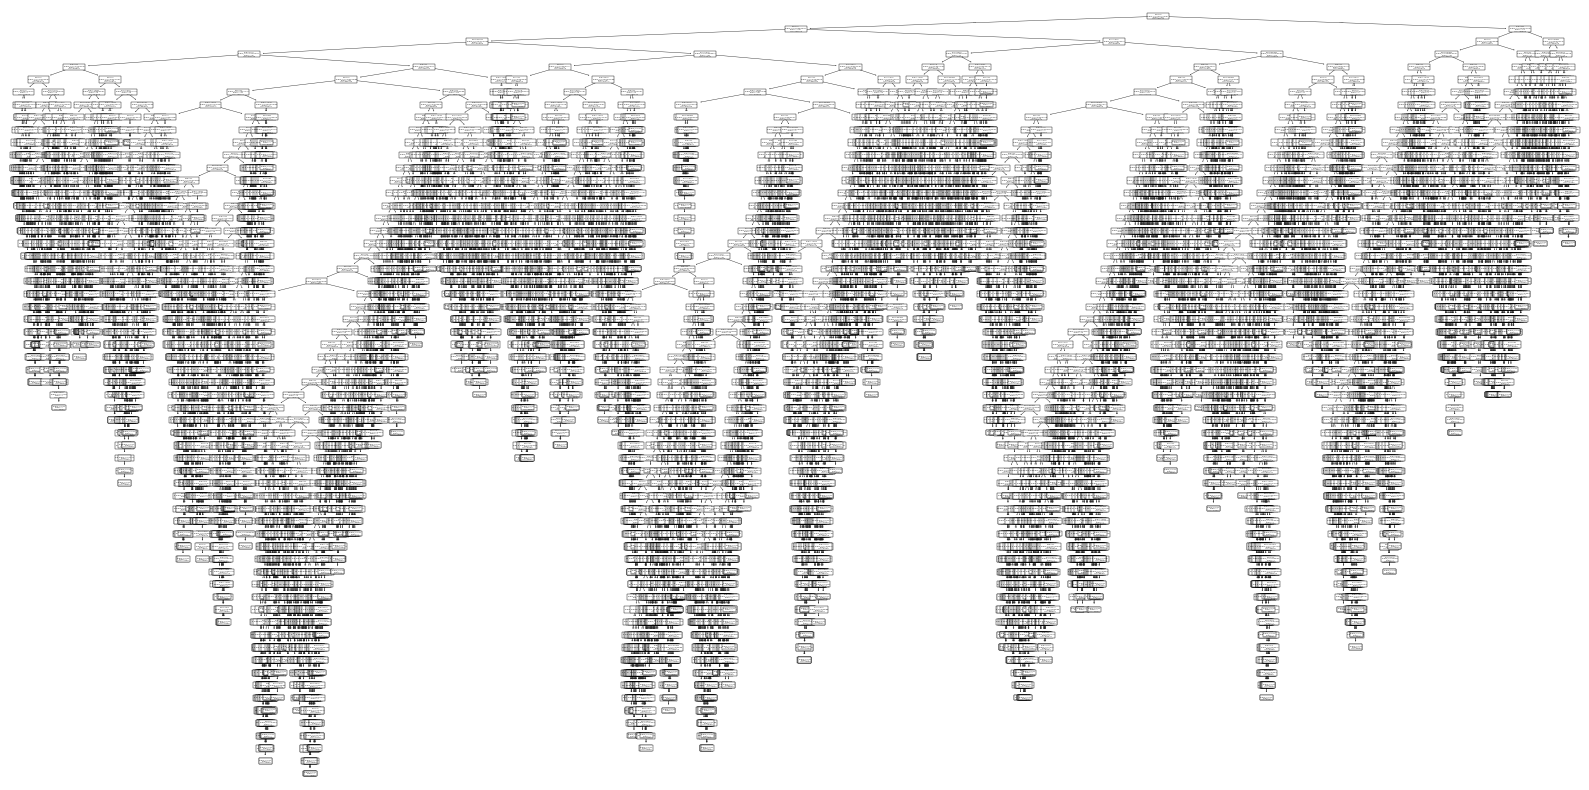

In [62]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dt);

In [63]:
# Deep Learning

Görünen o ki verilen kod bloğu King County ev fiyat tahmin projesi için geliştirilmiş kapsamlı bir makine öğrenmesi uygulaması. 
Aşağıda projenin ana bileşenleri ve özellikleri hakkında yorumlar yer almaktadır:

Veri Analizi ve Ön İşleme:

Veri seti olarak kc_house_data.csv dosyası kullanılmış.
Veri keşif analizi (EDA) yapılarak verilerin özellikleri ve değişkenler arası ilişkiler incelenmiş.
Aykırı değerler tespit edilip temizlenmiş.
Öznitelik mühendisliği ile yeni öznitelikler (bedrooms^2, bathrooms^2, sqft_living^2, age vb.) türetilmiş.
Modelleme:

Çeşitli regresyon algoritmaları (lineer regresyon, karar ağaçları, rassal ormanlar, XGBoost vb.) test edilmiş.
En iyi performans gösteren algoritma seçilmiş.
Değerlendirme:

Seçilen modelin test verileri üzerindeki R-kare ve RMSE değerleri hesaplanmış.
Hedeflenen başarı kriterlerinin (R-kare > 0.80, RMSE < $100K) karşılanıp karşılanmadığı kontrol edilmiş.
Görselleştirme:

Regresyon modellerinin performans karşılaştırmaları grafiksel olarak sunulmuş.
Modelin artık grafikleri ve tahmin hataları gibi görselleştirmeleri oluşturulmuş.
Sonuç:

Hedeflenen başarı kriterlerini karşılayan en iyi model seçilmiş.
Modelin yorumlanması ve gelecekteki uygulamalarda nasıl kullanılabileceği tartışılmış.
Genel olarak, kapsamlı bir veri analizi, makine öğrenmesi, görselleştirme ve model değerlendirme sürecini içeren bu proje,
King County ev fiyatlarını tahmin etmek için güvenilir ve performanslı bir model geliştirilmesini amaçlıyor. 
Projenin sonucunda elde edilen bilgiler ve öngörüler, gelecekteki emlak piyasası analizleri ve fiyatlandırma konularında kullanılabilir.